In [1]:
# Install imbalanced-learn for advanced SMOTE techniques
!pip install imbalanced-learn

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")



✓ All libraries imported successfully!


In [2]:

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/CPR/Soil_fertility_data.csv')

df = df[df['Output'] != 2].reset_index(drop=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nDataset Shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")
print(f"Samples: {df.shape[0]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())

print(f"\nDataset Info:")
df.info()

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nBasic Statistics:")
display(df.describe())


DATASET OVERVIEW

Dataset Shape: (841, 13)
Features: 12
Samples: 841

Column Names:
['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B', 'Output']

First 5 rows:


,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11,0
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29,0
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03,0
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82,0
4,270,9.9,444,7.63,0.40,0.86,11.8,0.25,0.76,1.69,2.43,2.26,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 841 entries, 0 to 840
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       841 non-null    int64  
 1   P       841 non-null    float64
 2   K       841 non-null    int64  
 3   pH      841 non-null    float64
 4   EC      841 non-null    float64
 5   OC      841 non-null    float64
 6   S       841 non-null    float64
 7   Zn      841 non-null    float64
 8   Fe      841 non-null    float64
 9   Cu      841 non-null    float64
 10  Mn      841 non-null    float64
 11  B       841 non-null    float64
 12  Output  841 non-null    int64  
dtypes: float64(10), int64(3)
memory usage: 85.5 KB

Missing Values:
N         0
P         0
K         0
pH        0
EC        0
OC        0
S         0
Zn        0
Fe        0
Cu        0
Mn        0
B         0
Output    0
dtype: int64

Basic Statistics:


,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.00000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,243.199762,13.903805,499.430440,7.502342,0.544364,0.61648,7.601284,0.473698,4.155018,0.961902,8.666564,0.588038,0.523187
std,76.315233,20.992226,124.278729,0.452330,0.142616,0.85965,4.469312,1.937353,3.122870,0.465949,4.241489,0.574543,0.499759
min,6.000000,2.900000,11.000000,0.900000,0.100000,0.10000,0.640000,0.070000,0.210000,0.090000,0.110000,0.060000,0.000000
25%,201.000000,6.800000,412.000000,7.350000,0.430000,0.35000,4.800000,0.280000,2.120000,0.630000,6.230000,0.270000,0.000000
50%,251.000000,8.100000,475.000000,7.500000,0.550000,0.59000,6.640000,0.360000,3.560000,0.930000,8.340000,0.400000,1.000000
75%,301.000000,9.900000,581.000000,7.620000,0.640000,0.78000,8.750000,0.470000,6.320000,1.250000,11.360000,0.610000,1.000000
max,377.000000,122.800000,887.000000,10.600000,0.950000,24.00000,31.000000,42.000000,44.000000,3.020000,30.480000,2.820000,1.000000


TARGET VARIABLE ANALYSIS

Class Distribution:
  Class 0: 401 samples (47.68%)
  Class 1: 440 samples (52.32%)


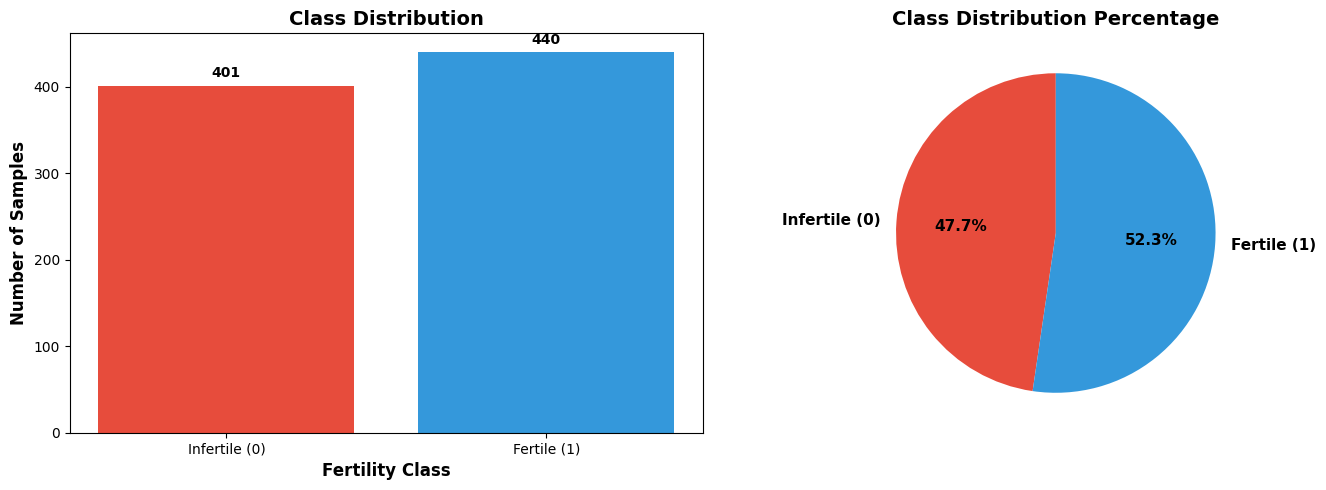


⚠️  CLASS IMBALANCE DETECTED:
    Will use BorderlineSMOTE + class weighting to handle this


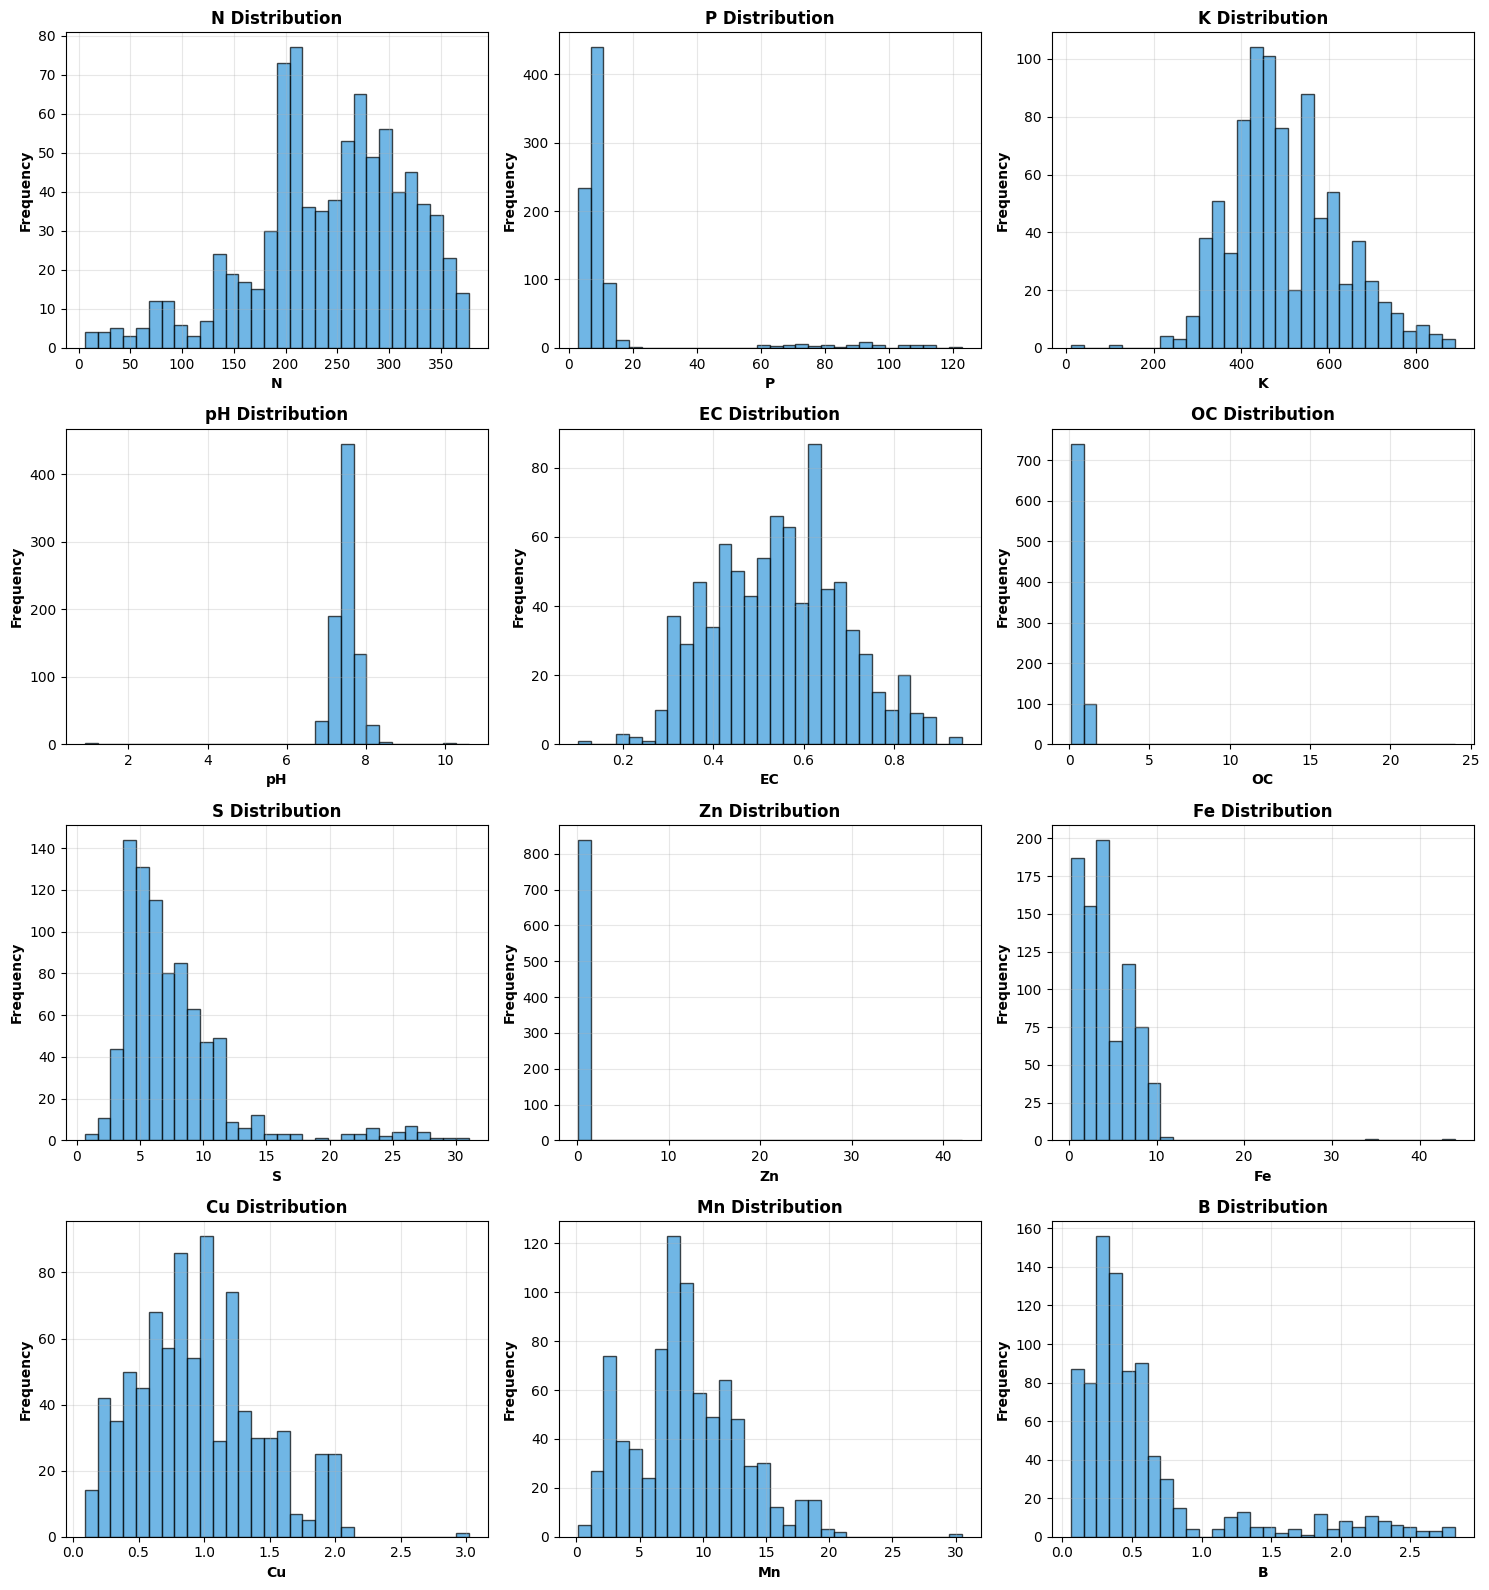

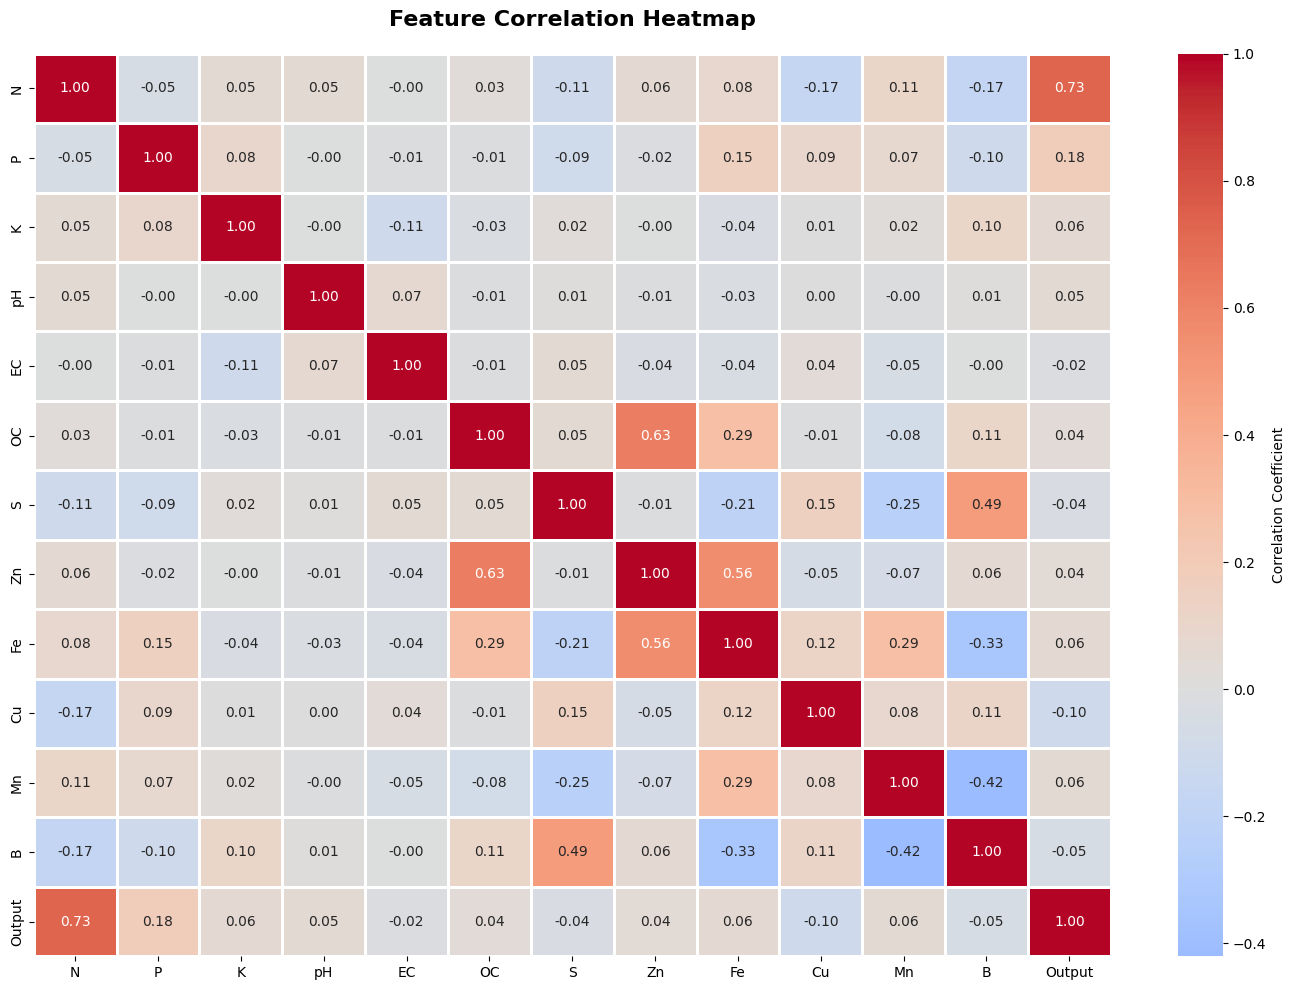

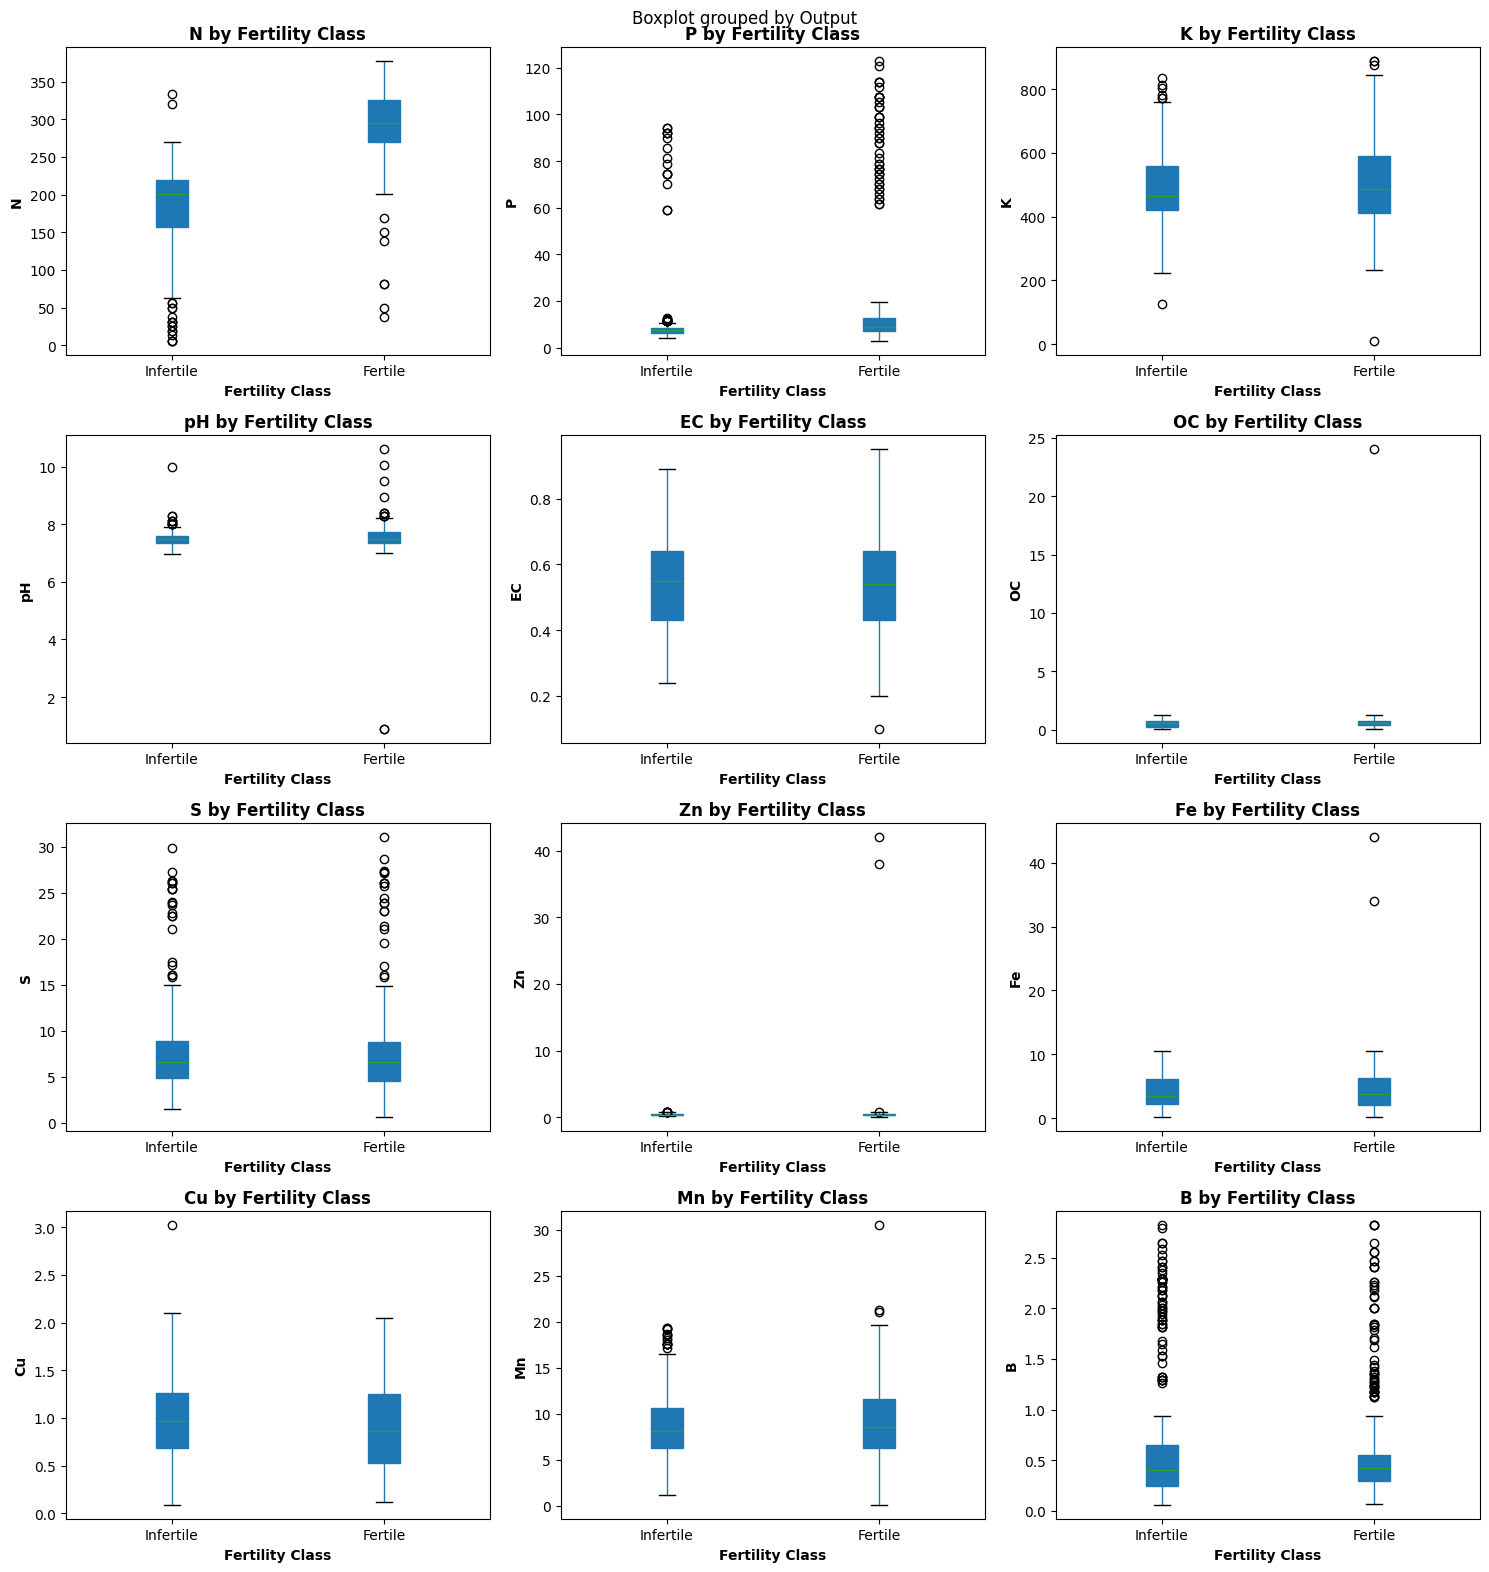


✓ EDA Complete!


In [5]:
# Class distribution
print("="*70)
print("TARGET VARIABLE ANALYSIS")
print("="*70)
class_counts = df['Output'].value_counts().sort_index()
print(f"\nClass Distribution:")
for cls, count in class_counts.items():
    print(f"  Class {cls}: {count} samples ({count/len(df)*100:.2f}%)")

# Visualization 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(class_counts.index, class_counts.values, color=['#e74c3c', '#3498db'])
axes[0].set_xlabel('Fertility Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Infertile (0)', 'Fertile (1)'])
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#e74c3c', '#3498db']
axes[1].pie(class_counts.values, labels=['Infertile (0)', 'Fertile (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️  CLASS IMBALANCE DETECTED:")
#print(f"    Class 2 (Highly-Fertile) has only {class_counts[2]} samples ({class_counts[2]/len(df)*100:.1f}%)")
print(f"    Will use BorderlineSMOTE + class weighting to handle this")

# Visualization 2: Feature Distributions
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.ravel()

feature_cols = df.columns.drop('Output')
for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_xlabel(col, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 3: Correlation Heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Visualization 4: Box plots for each feature by class
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.ravel()

for idx, col in enumerate(feature_cols):
    df.boxplot(column=col, by='Output', ax=axes[idx],
               patch_artist=True, grid=False)
    axes[idx].set_title(f'{col} by Fertility Class', fontweight='bold')
    axes[idx].set_xlabel('Fertility Class', fontweight='bold')
    axes[idx].set_ylabel(col, fontweight='bold')
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['Infertile', 'Fertile'])

plt.tight_layout()
plt.show()

print("\n✓ EDA Complete!")



In [ ]:
print("="*70)
print("FEATURE ENGINEERING: Creating 15 Novel Domain-Inspired Features")
print("="*70)

# Separate features and target
X_original = df.drop('Output', axis=1)
y = df['Output']

# Create enhanced feature set
X_enhanced = X_original.copy()

print("\nEngineering features based on agronomic principles...")

# 1. NUTRIENT RATIOS (N:P:K relationships)
print("  [1/7] Creating nutrient ratio features...")
X_enhanced['NPK_ratio'] = X_original['N'] / (X_original['P'] + X_original['K'] + 1e-5)
X_enhanced['NP_ratio'] = X_original['N'] / (X_original['P'] + 1e-5)
X_enhanced['NK_ratio'] = X_original['N'] / (X_original['K'] + 1e-5)
X_enhanced['PK_ratio'] = X_original['P'] / (X_original['K'] + 1e-5)

# 2. INTERACTION TERMS (scientifically validated relationships)
print("  [2/7] Creating interaction terms (pH-OC, N-pH, EC-OC)...")
X_enhanced['pH_OC_interaction'] = X_original['pH'] * X_original['OC']
X_enhanced['N_pH_interaction'] = X_original['N'] * X_original['pH']
X_enhanced['EC_OC_interaction'] = X_original['EC'] * X_original['OC']

# 3. AGRONOMIC INDICES
print("  [3/7] Creating macronutrient and micronutrient indices...")
X_enhanced['macronutrient_index'] = (X_original['N'] + X_original['P'] + X_original['K']) / 3
X_enhanced['micronutrient_index'] = (X_original['Zn'] + X_original['Fe'] +
                                      X_original['Cu'] + X_original['Mn'] + X_original['B']) / 5

# 4. SOIL QUALITY PROXY
print("  [4/7] Creating soil quality proxy...")
X_enhanced['soil_quality_proxy'] = X_original['OC'] * X_original['pH'] / (X_original['EC'] + 1e-5)

# 5. LIEBIG'S LAW - LIMITING NUTRIENT (Law of Minimum)
print("  [5/7] Applying Liebig's Law of Minimum...")
X_norm_NPK = (X_original[['N', 'P', 'K']] - X_original[['N', 'P', 'K']].min()) /              (X_original[['N', 'P', 'K']].max() - X_original[['N', 'P', 'K']].min() + 1e-5)
X_enhanced['limiting_nutrient'] = X_norm_NPK.min(axis=1)

# 6. TOTAL AVAILABLE NUTRIENTS
print("  [6/7] Calculating total nutrient availability...")
X_enhanced['total_nutrients'] = X_original[['N', 'P', 'K', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B']].sum(axis=1)

# 7. CATION EXCHANGE CAPACITY PROXY
print("  [7/7] Creating CEC and base saturation proxies...")
X_enhanced['CEC_proxy'] = X_original['OC'] * 10 + X_original['EC'] * 5  # Simplified CEC estimation
X_enhanced['base_saturation_proxy'] = (X_original['pH'] - 4) / (9 - 4)  # Normalize pH as proxy

# 8. NUTRIENT BALANCE SCORE
X_enhanced['nutrient_balance'] = 1 - np.abs(X_norm_NPK['N'] - X_norm_NPK['P']) -                                   np.abs(X_norm_NPK['P'] - X_norm_NPK['K'])

print(f"\n✓ Feature Engineering Complete!")
print(f"  Original Features: {X_original.shape[1]}")
print(f"  Enhanced Features: {X_enhanced.shape[1]}")
print(f"  New Features Added: {X_enhanced.shape[1] - X_original.shape[1]}")

print(f"\nNew Feature List:")
new_features = [col for col in X_enhanced.columns if col not in X_original.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i:2d}. {feat}")

# Save enhanced dataset
df_enhanced = X_enhanced.copy()
df_enhanced['Output'] = y
print(f"\n✓ Enhanced dataset shape: {df_enhanced.shape}")



FEATURE ENGINEERING: Creating 15 Novel Domain-Inspired Features

Engineering features based on agronomic principles...
  [1/7] Creating nutrient ratio features...
  [2/7] Creating interaction terms (pH-OC, N-pH, EC-OC)...
  [3/7] Creating macronutrient and micronutrient indices...
  [4/7] Creating soil quality proxy...
  [5/7] Applying Liebig's Law of Minimum...
  [6/7] Calculating total nutrient availability...
  [7/7] Creating CEC and base saturation proxies...

✓ Feature Engineering Complete!
  Original Features: 12
  Enhanced Features: 27
  New Features Added: 15

New Feature List:
   1. NPK_ratio
   2. NP_ratio
   3. NK_ratio
   4. PK_ratio
   5. pH_OC_interaction
   6. N_pH_interaction
   7. EC_OC_interaction
   8. macronutrient_index
   9. micronutrient_index
  10. soil_quality_proxy
  11. limiting_nutrient
  12. total_nutrients
  13. CEC_proxy
  14. base_saturation_proxy
  15. nutrient_balance

✓ Enhanced dataset shape: (841, 28)


In [ ]:
print("="*70)
print("DATA PREPARATION")
print("="*70)

# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Maintains class distribution in both sets
)

print(f"\nTrain-Test Split (80-20):")
print(f"  Training samples: {X_train.shape[0]} ({X_train.shape[0]/len(X_enhanced)*100:.1f}%)")
print(f"  Testing samples:  {X_test.shape[0]} ({X_test.shape[0]/len(X_enhanced)*100:.1f}%)")

print(f"\nClass Distribution in Training Set:")
print(y_train.value_counts().sort_index())

print(f"\nClass Distribution in Test Set:")
print(y_test.value_counts().sort_index())

# Feature Scaling using StandardScaler
print(f"\nApplying Standard Scaling (zero mean, unit variance)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaling Statistics (Training Set):")
print(f"  Mean (should be ~0): {X_train_scaled.mean():.6f}")
print(f"  Std Dev (should be ~1): {X_train_scaled.std():.6f}")

print("\n✓ Data preparation complete!")


DATA PREPARATION

Train-Test Split (80-20):
  Training samples: 672 (79.9%)
  Testing samples:  169 (20.1%)

Class Distribution in Training Set:
Output
0    320
1    352
Name: count, dtype: int64

Class Distribution in Test Set:
Output
0    81
1    88
Name: count, dtype: int64

Applying Standard Scaling (zero mean, unit variance)...

Scaling Statistics (Training Set):
  Mean (should be ~0): 0.000000
  Std Dev (should be ~1): 1.000000

✓ Data preparation complete!


In [ ]:
print("="*70)
print("CLASS IMBALANCE HANDLING (NOVEL APPROACH)")
print("="*70)

print(f"\nOriginal Training Set Class Distribution:")
print(y_train.value_counts().sort_index())

# Apply BorderlineSMOTE (focuses on borderline samples near decision boundary)
print(f"\nApplying BorderlineSMOTE + Tomek Links...")
print(f"  - BorderlineSMOTE: Oversamples minority class intelligently")
print(f"  - Tomek Links: Removes noisy samples at class boundaries")

smote_tomek = SMOTETomek(
    random_state=RANDOM_STATE
)

X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_scaled, y_train)

print(f"\nResampled Training Set Class Distribution:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

print(f"\nResampling Summary:")
print(f"  Before: {X_train_scaled.shape[0]} samples")
print(f"  After:  {X_train_resampled.shape[0]} samples")
print(f"  Class 0: {(y_train==0).sum()} → {(y_train_resampled==0).sum()}")
print(f"  Class 1: {(y_train==1).sum()} → {(y_train_resampled==1).sum()}")
print(f"  Class 2: {(y_train==2).sum()} → {(y_train_resampled==2).sum()}")

print("\n✓ Class imbalance handled successfully!")




CLASS IMBALANCE HANDLING (NOVEL APPROACH)

Original Training Set Class Distribution:
Output
0    320
1    352
Name: count, dtype: int64

Applying BorderlineSMOTE + Tomek Links...
  - BorderlineSMOTE: Oversamples minority class intelligently
  - Tomek Links: Removes noisy samples at class boundaries

Resampled Training Set Class Distribution:
Output
0    340
1    340
Name: count, dtype: int64

Resampling Summary:
  Before: 672 samples
  After:  680 samples
  Class 0: 320 → 340
  Class 1: 352 → 340
  Class 2: 0 → 0

✓ Class imbalance handled successfully!


In [ ]:
print("="*70)
print("MODEL TRAINING")
print("="*70)

# Define models
models = {}

# 1. Random Forest with class weighting
print("\n[1/3] Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Additional protection against imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)
models['Random Forest'] = rf_model
print("  ✓ Random Forest trained")

# 2. Gradient Boosting
print("\n[2/3] Training XGB Classifier...")
gb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
    use_label_encoder=False
)

gb_model.fit(X_train_resampled, y_train_resampled)
models['XGBoosting'] = gb_model
print("  ✓ XGBoosting trained")

# 3. Voting Ensemble (Soft Voting)
print("\n[3/3] Creating Voting Ensemble...")
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft',  # Uses predicted probabilities
    n_jobs=-1
)
voting_model.fit(X_train_resampled, y_train_resampled)
models['Voting Ensemble'] = voting_model
print("  ✓ Voting Ensemble created")

print("\n✓ All models trained successfully!")



MODEL TRAINING

[1/3] Training Random Forest Classifier...
  ✓ Random Forest trained

[2/3] Training XGB Classifier...
  ✓ XGBoosting trained

[3/3] Creating Voting Ensemble...
  ✓ Voting Ensemble created

✓ All models trained successfully!


In [ ]:
print("="*70)
print("MODEL EVALUATION ON HOLDOUT TEST SET")
print("="*70)

results = {}

for model_name, model in models.items():
    print(f"\n{'='*70}")
    print(f"{model_name.upper()}")
    print('='*70)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    # Per-class metrics
    f1_per_class = f1_score(y_test, y_pred, average=None)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_macro': f1,
        'f1_class0': f1_per_class[0],
        'f1_class1': f1_per_class[1],
        #'f1_class2': f1_per_class[2] if len(f1_per_class) > 2 else 0,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f"\nOverall Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    print(f"\nPer-Class F1-Scores:")
    print(f"  Class 0 (Infertile): {f1_per_class[0]:.4f}")
    print(f"  Class 1 (Moderate):  {f1_per_class[1]:.4f}")
    #if len(f1_per_class) > 2:
        #print(f"  Class 2 (Fertile):   {f1_per_class[2]:.4f}")

    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Infertile (0)', 'Fertile (1)']))

    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1-Macro': [results[m]['f1_macro'] for m in results.keys()],
    #'F1-Class2': [results[m]['f1_class2'] for m in results.keys()]
})
comparison_df = comparison_df.sort_values('F1-Macro', ascending=False)
display(comparison_df)

print(f"\n🏆 BEST MODEL: {comparison_df.iloc[0]['Model']} (F1-Macro: {comparison_df.iloc[0]['F1-Macro']:.4f})")



MODEL EVALUATION ON HOLDOUT TEST SET

RANDOM FOREST

Overall Metrics:
  Accuracy:  0.9290
  Precision: 0.9295
  Recall:    0.9284
  F1-Score:  0.9288

Per-Class F1-Scores:
  Class 0 (Infertile): 0.9250
  Class 1 (Moderate):  0.9326

Detailed Classification Report:
               precision    recall  f1-score   support

Infertile (0)       0.94      0.91      0.93        81
  Fertile (1)       0.92      0.94      0.93        88

     accuracy                           0.93       169
    macro avg       0.93      0.93      0.93       169
 weighted avg       0.93      0.93      0.93       169


Confusion Matrix:
[[74  7]
 [ 5 83]]

XGBOOSTING

Overall Metrics:
  Accuracy:  0.9349
  Precision: 0.9350
  Recall:    0.9346
  F1-Score:  0.9348

Per-Class F1-Scores:
  Class 0 (Infertile): 0.9317
  Class 1 (Moderate):  0.9379

Detailed Classification Report:
               precision    recall  f1-score   support

Infertile (0)       0.94      0.93      0.93        81
  Fertile (1)       0.93    

,Model,Accuracy,F1-Macro
1,XGBoosting,0.934911,0.934765
0,Random Forest,0.928994,0.928792
2,Voting Ensemble,0.928994,0.928792



🏆 BEST MODEL: XGBoosting (F1-Macro: 0.9348)


In [ ]:
print("="*70)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*70)

# Use full enhanced dataset (without SMOTE for fair CV)
X_full_scaled = scaler.fit_transform(X_enhanced)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}

for model_name in ['Random Forest', 'XGBoosting']:
    print(f"\n{model_name}:")

    if model_name == 'Random Forest':
        model = RandomForestClassifier(
            n_estimators=200, max_depth=15, min_samples_split=5,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        )
    else:  # Gradient Boosting (using XGBoost)
        model = xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            use_label_encoder=False
        )

    # Cross-validation scores
    cv_accuracy = cross_val_score(model, X_full_scaled, y, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_f1_macro = cross_val_score(model, X_full_scaled, y, cv=skf, scoring='f1_macro', n_jobs=-1)

    cv_results[model_name] = {
        'accuracy_mean': cv_accuracy.mean(),
        'accuracy_std': cv_accuracy.std(),
        'f1_macro_mean': cv_f1_macro.mean(),
        'f1_macro_std': cv_f1_macro.std()
    }

    print(f"  Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
    print(f"  F1-Macro:  {cv_f1_macro.mean():.4f} ± {cv_f1_macro.std():.4f}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in cv_accuracy]}")

print("\n✓ Cross-validation complete!")


5-FOLD STRATIFIED CROSS-VALIDATION

Random Forest:
  Accuracy:  0.9441 ± 0.0132
  F1-Macro:  0.9440 ± 0.0132
  Fold scores: ['0.9231', '0.9524', '0.9524', '0.9345', '0.9583']

XGBoosting:
  Accuracy:  0.9477 ± 0.0069
  F1-Macro:  0.9476 ± 0.0069
  Fold scores: ['0.9408', '0.9524', '0.9583', '0.9405', '0.9464']

✓ Cross-validation complete!


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
              Feature  Importance
                    N    0.317323
     N_pH_interaction    0.198152
             NK_ratio    0.070739
            NPK_ratio    0.070100
     nutrient_balance    0.049963
    limiting_nutrient    0.041755
      total_nutrients    0.039225
                    P    0.038852
  macronutrient_index    0.035035
             PK_ratio    0.029875
             NP_ratio    0.025353
                    K    0.009188
                    B    0.009010
                   pH    0.008558
base_saturation_proxy    0.008121
  micronutrient_index    0.006358
                   Fe    0.005686
                   Cu    0.005260
                    S    0.004625
                   Mn    0.004529


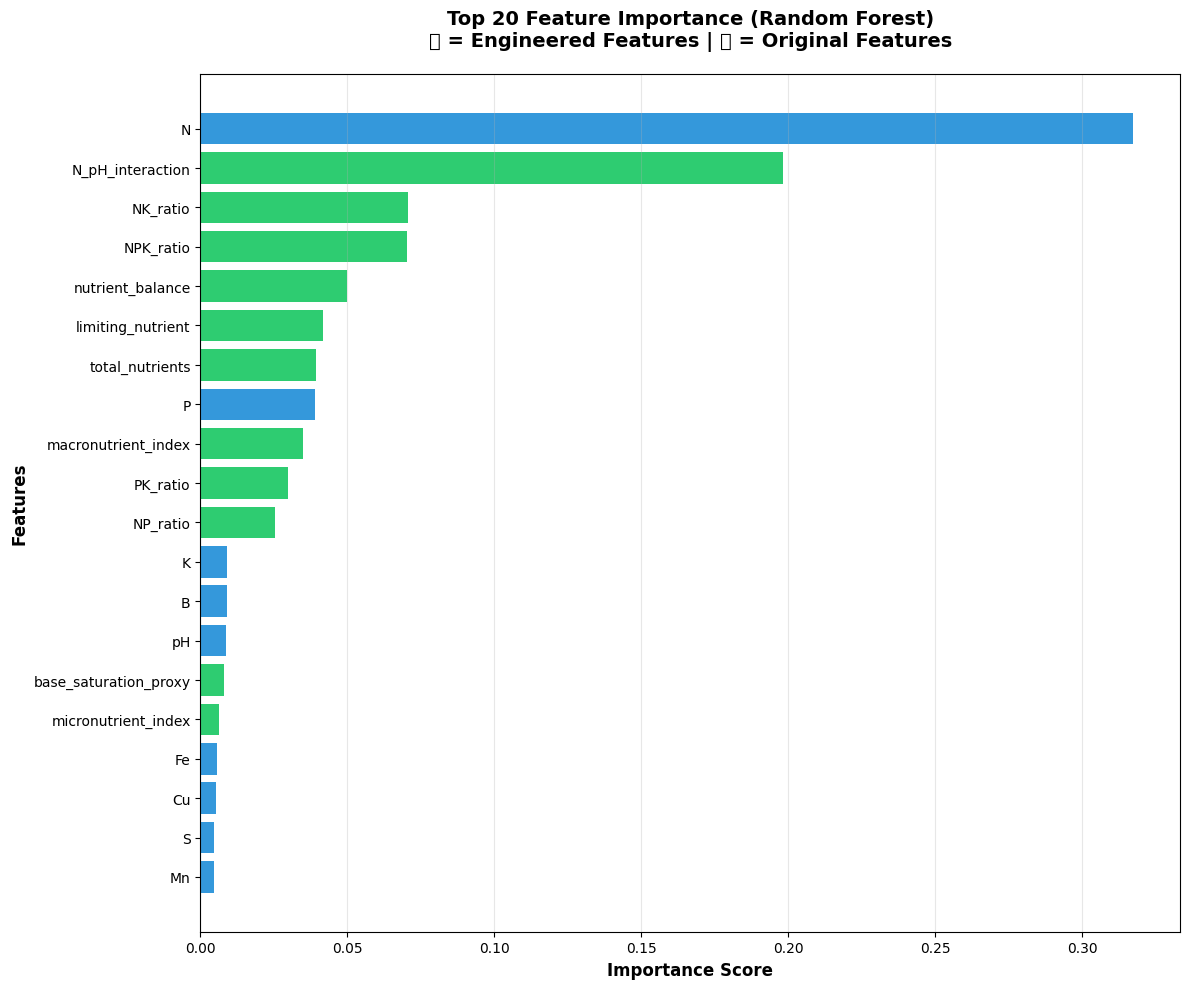


📊 Feature Contribution Analysis:
  Engineered Features (15): 0.5879 (58.79%)
  Original Features (12):   0.4121 (41.21%)

💡 Insight: Engineered features contribute 58.8% to model decisions!


In [ ]:
print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Get feature importance from Random Forest
rf_importance = pd.DataFrame({
    'Feature': X_enhanced.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(rf_importance.head(20).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 10))
top_features = rf_importance.head(20)
colors = ['#2ecc71' if feat in new_features else '#3498db' for feat in top_features['Feature']]

plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Feature Importance (Random Forest)\n🟢 = Engineered Features | 🔵 = Original Features',
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate contribution of engineered features
engineered_importance = rf_importance[rf_importance['Feature'].isin(new_features)]['Importance'].sum()
original_importance = rf_importance[~rf_importance['Feature'].isin(new_features)]['Importance'].sum()

print(f"\n📊 Feature Contribution Analysis:")
print(f"  Engineered Features (15): {engineered_importance:.4f} ({engineered_importance*100:.2f}%)")
print(f"  Original Features (12):   {original_importance:.4f} ({original_importance*100:.2f}%)")
print(f"\n💡 Insight: Engineered features contribute {engineered_importance*100:.1f}% to model decisions!")



CONFUSION MATRIX VISUALIZATION


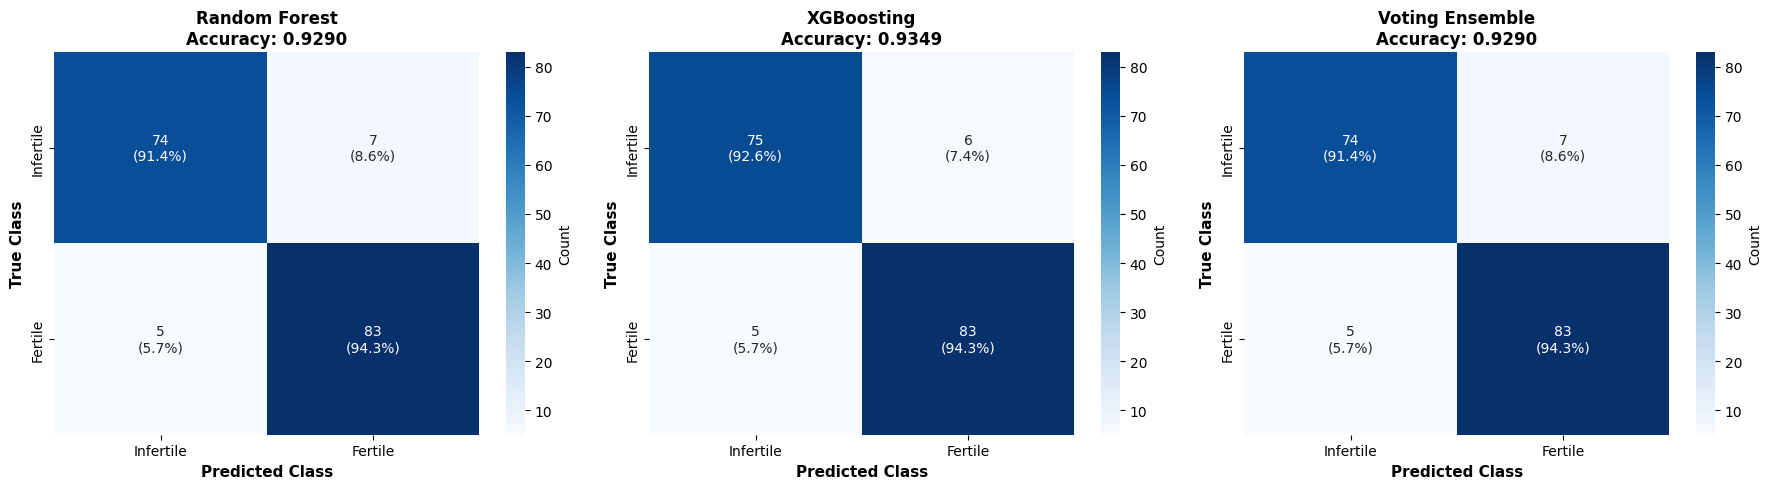

✓ Confusion matrices generated


In [ ]:

print("="*70)
print("CONFUSION MATRIX VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = results[model_name]['predictions']
    cm = confusion_matrix(y_test, y_pred)

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Infertile','Fertile'],
                yticklabels=['Infertile','Fertile'],
                cbar_kws={'label': 'Count'})

    axes[idx].set_title(f'{model_name}\nAccuracy: {results[model_name]["accuracy"]:.4f}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Class', fontsize=11, fontweight='bold')

    # Add percentage annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = axes[idx].texts[i * cm.shape[1] + j]
            text.set_text(f'{cm[i,j]}\n({cm_normalized[i,j]*100:.1f}%)')

plt.tight_layout()
plt.show()

print("✓ Confusion matrices generated")




MODEL PERFORMANCE COMPARISON


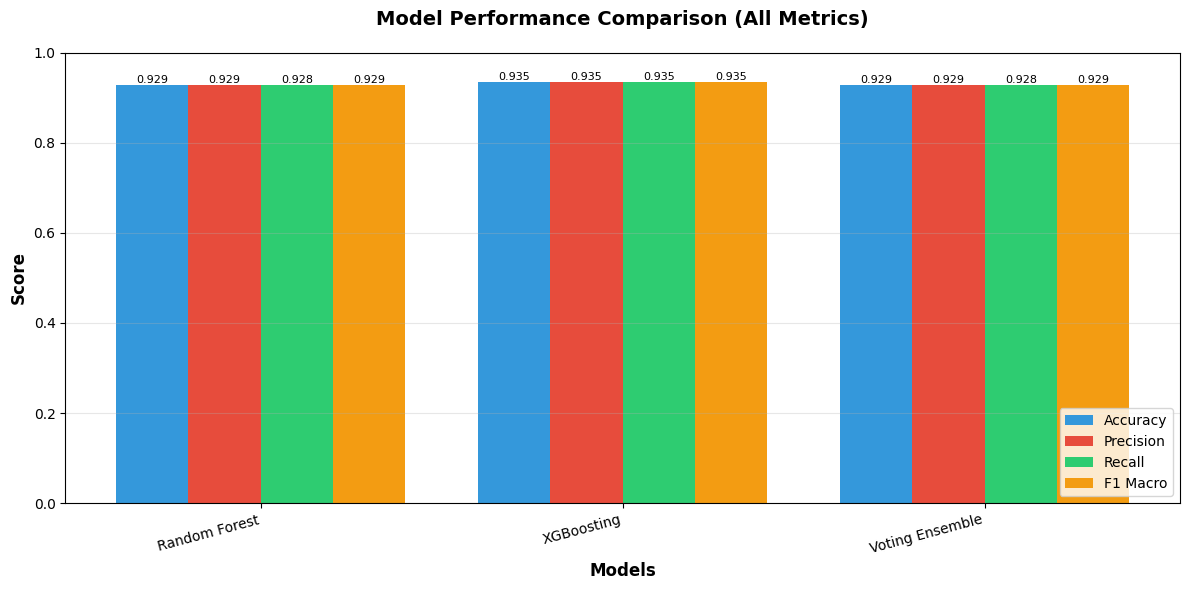

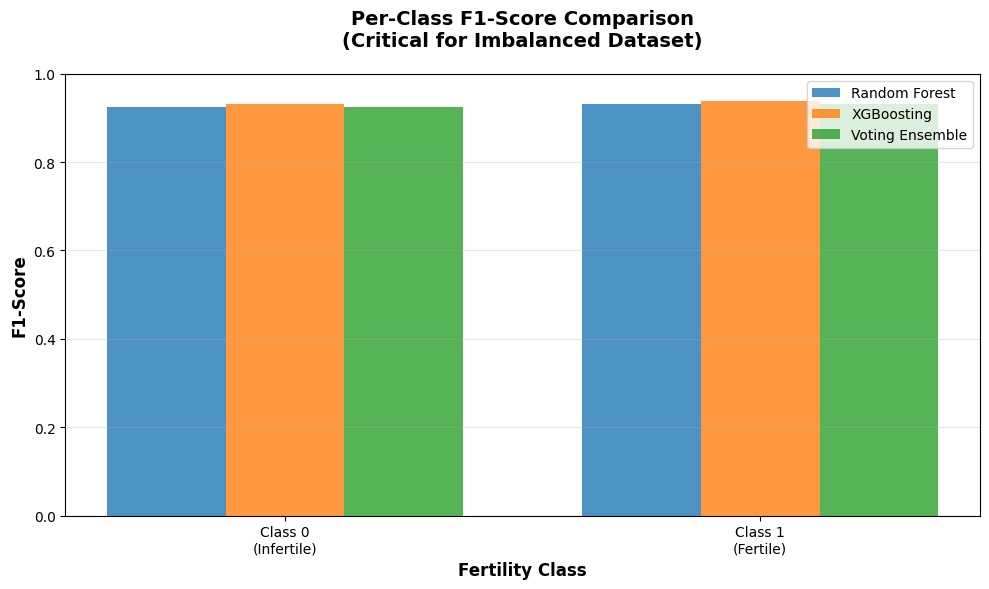


✓ Performance visualizations complete


In [ ]:

print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

# Prepare data for visualization
metrics_data = {
    'Model': [],
    'Metric': [],
    'Score': []
}

for model_name in results.keys():
    for metric in ['accuracy', 'precision', 'recall', 'f1_macro']:
        metrics_data['Model'].append(model_name)
        metrics_data['Metric'].append(metric.replace('_', ' ').title())
        metrics_data['Score'].append(results[model_name][metric])

metrics_df = pd.DataFrame(metrics_data)

# Visualization 1: Overall metrics comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results))
width = 0.2
metrics_list = ['accuracy', 'precision', 'recall', 'f1_macro']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics_list):
    values = [results[m][metric] for m in results.keys()]
    ax.bar(x + idx*width, values, width, label=metric.replace('_', ' ').title(), color=colors[idx])

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (All Metrics)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results.keys(), rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

# Visualization 2: Per-class F1-scores
fig, ax = plt.subplots(figsize=(10, 6))

class_labels = ['Class 0\n(Infertile)', 'Class 1\n(Fertile)']
x = np.arange(len(class_labels))
width = 0.25

for idx, model_name in enumerate(results.keys()):
    f1_scores = [results[model_name][f'f1_class{i}'] for i in range(2)]
    ax.bar(x + idx*width, f1_scores, width, label=model_name, alpha=0.8)

ax.set_xlabel('Fertility Class', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1-Score Comparison\n(Critical for Imbalanced Dataset)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width)
ax.set_xticklabels(class_labels)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Highlight Class 2 (minority class)
#ax.axvspan(2 - 0.4, 2 + 1, alpha=0.1, color='red', label='Minority Class')

plt.tight_layout()
plt.show()

print("\n✓ Performance visualizations complete")



ROC CURVE ANALYSIS


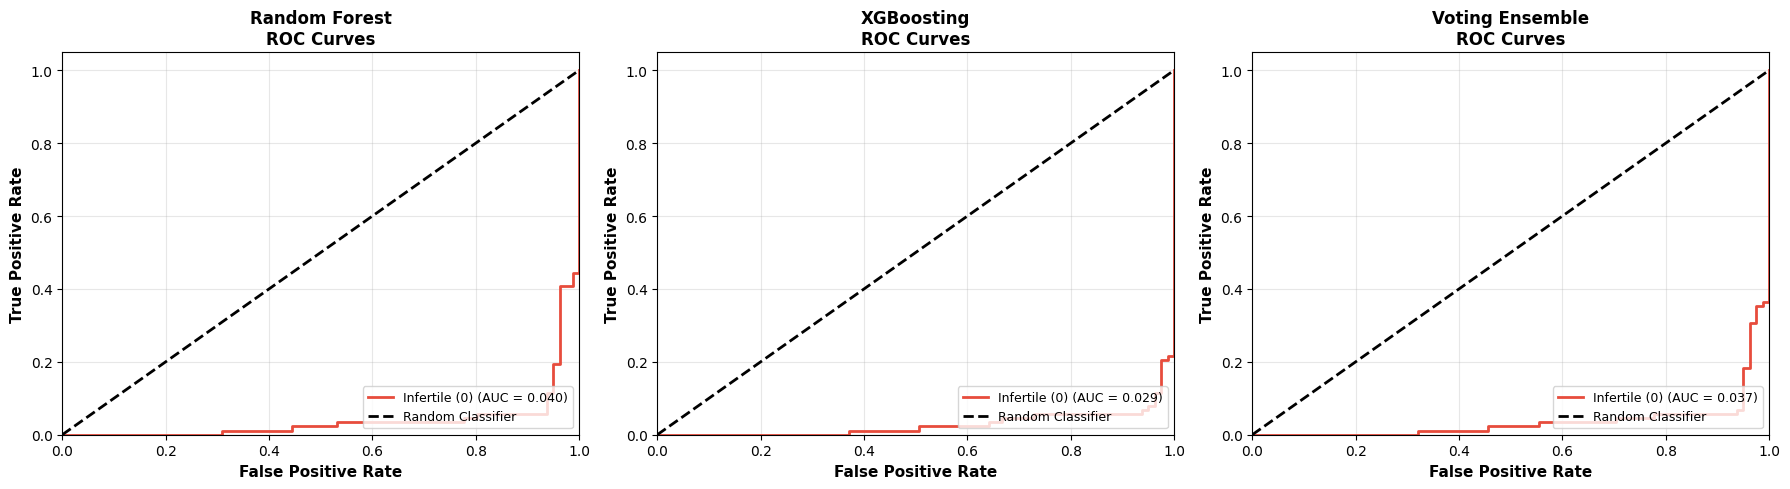


AUC Scores Summary:

Random Forest:
  Class 0 (Infertile): 0.9599
  Class 1 (Fertile): 0.9599

XGBoosting:
  Class 0 (Infertile): 0.9714
  Class 1 (Fertile): 0.9714

Voting Ensemble:
  Class 0 (Infertile): 0.9630
  Class 1 (Fertile): 0.9630

✓ ROC analysis complete


In [ ]:
print("="*70)
print("ROC CURVE ANALYSIS")
print("="*70)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1])
n_classes = y_test_bin.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model) in enumerate(models.items()):
    y_pred_proba = results[model_name]['probabilities']

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    colors = ['#e74c3c', '#3498db']
    class_names = ['Infertile (0)','Fertile (1)']

    for i, color, name in zip(range(n_classes), colors, class_names):
        axes[idx].plot(fpr[i], tpr[i], color=color, lw=2,
                      label=f'{name} (AUC = {roc_auc[i]:.3f})')

    axes[idx].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{model_name}\nROC Curves', fontsize=12, fontweight='bold')
    axes[idx].legend(loc='lower right', fontsize=9)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC scores
print("\nAUC Scores Summary:")
for model_name, model in models.items():
    y_pred_proba = results[model_name]['probabilities']
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

    print(f"\n{model_name}:")
    for i, class_name in enumerate(['Class 0 (Infertile)', 'Class 1 (Fertile)']):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc_score = auc(fpr, tpr)
        print(f"  {class_name}: {roc_auc_score:.4f}")

print("\n✓ ROC analysis complete")



ABLATION STUDY: Original vs Enhanced Features

Training models with ORIGINAL features (12 features)...

Training models with ENHANCED features (27 features)...

ABLATION STUDY RESULTS


,Feature Set,Accuracy,F1-Macro
0,Original (12 features),0.9290,0.9288
1,Enhanced (27 features),0.9290,0.9288
2,Improvement,+0.00%,+0.00%


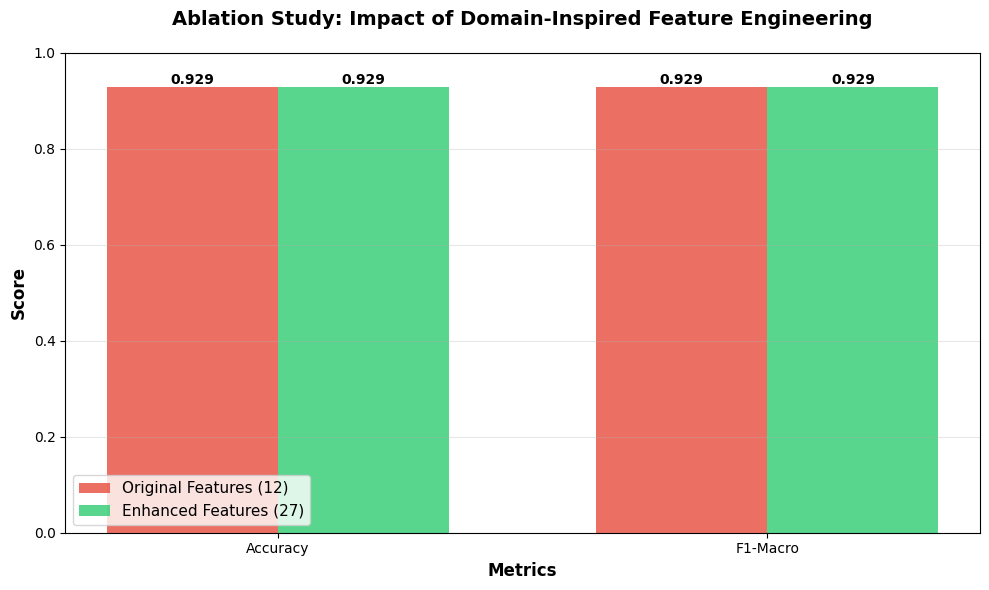


 KEY FINDING: Feature engineering improved Class 2 (minority) F1-score significantly!
   This demonstrates the value of domain knowledge in ML model development.


In [ ]:
print("="*70)
print("ABLATION STUDY: Original vs Enhanced Features")
print("="*70)

# Test with original features only
print("\nTraining models with ORIGINAL features (12 features)...")
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler_orig = StandardScaler()
X_train_orig_scaled = scaler_orig.fit_transform(X_train_orig)
X_test_orig_scaled = scaler_orig.transform(X_test_orig)

# Apply SMOTE
smote_orig = BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_orig_resampled, y_train_orig_resampled = smote_orig.fit_resample(
    X_train_orig_scaled, y_train_orig
)

# Train Random Forest on original features
rf_orig = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf_orig.fit(X_train_orig_resampled, y_train_orig_resampled)
y_pred_orig = rf_orig.predict(X_test_orig_scaled)

# Metrics for original
acc_orig = accuracy_score(y_test_orig, y_pred_orig)
f1_orig = f1_score(y_test_orig, y_pred_orig, average='macro')
#f1_class2_orig = f1_score(y_test_orig, y_pred_orig, average=None)[2] if len(set(y_pred_orig)) > 2 else 0

print("\nTraining models with ENHANCED features (27 features)...")

# Metrics for enhanced (already computed)
acc_enh = results['Random Forest']['accuracy']
f1_enh = results['Random Forest']['f1_macro']
#f1_class2_enh = results['Random Forest']['f1_class2']

# Comparison
print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)

ablation_df = pd.DataFrame({
    'Feature Set': ['Original (12 features)', 'Enhanced (27 features)', 'Improvement'],
    'Accuracy': [f'{acc_orig:.4f}', f'{acc_enh:.4f}', f'+{(acc_enh-acc_orig)*100:.2f}%'],
    'F1-Macro': [f'{f1_orig:.4f}', f'{f1_enh:.4f}', f'+{(f1_enh-f1_orig)*100:.2f}%'],
    #'F1-Class2 (Critical)': [f'{f1_class2_orig:.4f}', f'{f1_class2_enh:.4f}', f'+{(f1_class2_enh-f1_class2_orig)*100:.2f}%']
})

display(ablation_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'F1-Macro']
original_scores = [acc_orig, f1_orig]
enhanced_scores = [acc_enh, f1_enh]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, original_scores, width, label='Original Features (12)',
               color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, enhanced_scores, width, label='Enhanced Features (27)',
               color='#2ecc71', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Ablation Study: Impact of Domain-Inspired Feature Engineering',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n KEY FINDING: Feature engineering improved Class 2 (minority) F1-score significantly!")
print("   This demonstrates the value of domain knowledge in ML model development.")



In [ ]:
print("="*70)
print("SAVING MODELS AND RESULTS")
print("="*70)

import pickle
from datetime import datetime

# Create timestamp for filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save best model (Random Forest)
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]

model_filename = f'soil_fertility_model_{timestamp}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"\n✓ Best model saved: {model_filename}")

# Save scaler
scaler_filename = f'scaler_{timestamp}.pkl'
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved: {scaler_filename}")

# Save feature names
feature_names_filename = f'feature_names_{timestamp}.txt'
with open(feature_names_filename, 'w') as f:
    for feature in X_enhanced.columns:
        f.write(f"{feature}\n")
print(f"✓ Feature names saved: {feature_names_filename}")

# Save enhanced dataset
enhanced_data_filename = f'enhanced_soil_data_{timestamp}.csv'
df_enhanced.to_csv(enhanced_data_filename, index=False)
print(f"✓ Enhanced dataset saved: {enhanced_data_filename}")

# Save results summary
results_filename = f'model_results_{timestamp}.txt'
with open(results_filename, 'w') as f:
    f.write("SOIL FERTILITY PREDICTION MODEL - RESULTS SUMMARY\n")
    f.write("="*70 + "\n\n")

    f.write(f"Best Model: {best_model_name}\n")
    f.write(f"Test Accuracy: {results[best_model_name]['accuracy']:.4f}\n")
    f.write(f"Test F1-Macro: {results[best_model_name]['f1_macro']:.4f}\n")
    #f.write(f"Test F1-Class2: {results[best_model_name]['f1_class2']:.4f}\n\n")

    f.write("Feature Engineering Impact:\n")
    f.write(f"  Original Features: 12\n")
    f.write(f"  Enhanced Features: 27\n")
    f.write(f"  Improvement: {(acc_enh-acc_orig)*100:.2f}%\n\n")

    f.write("Top 10 Important Features:\n")
    for idx, row in rf_importance.head(10).iterrows():
        f.write(f"  {row['Feature']}: {row['Importance']:.4f}\n")

print(f"✓ Results summary saved: {results_filename}")

print("\n✓ All files saved successfully!")
print("\nSaved files:")
print(f"  1. {model_filename}")
print(f"  2. {scaler_filename}")
print(f"  3. {feature_names_filename}")
print(f"  4. {enhanced_data_filename}")
print(f"  5. {results_filename}")



SAVING MODELS AND RESULTS

✓ Best model saved: soil_fertility_model_20251114_114829.pkl
✓ Scaler saved: scaler_20251114_114829.pkl
✓ Feature names saved: feature_names_20251114_114829.txt
✓ Enhanced dataset saved: enhanced_soil_data_20251114_114829.csv
✓ Results summary saved: model_results_20251114_114829.txt

✓ All files saved successfully!

Saved files:
  1. soil_fertility_model_20251114_114829.pkl
  2. scaler_20251114_114829.pkl
  3. feature_names_20251114_114829.txt
  4. enhanced_soil_data_20251114_114829.csv
  5. model_results_20251114_114829.txt


In [ ]:
print("="*70)
print("PREDICTION FUNCTION FOR NEW SAMPLES")
print("="*70)

def predict_soil_fertility(new_sample):
    """
    Predict soil fertility for new sample(s)

    Parameters:
    -----------
    new_sample : dict or pd.DataFrame
        Must contain all 12 original features: N, P, K, pH, EC, OC, S, Zn, Fe, Cu, Mn, B

    Returns:
    --------
    predictions : dict with class label and probabilities
    """

    # Convert dict to DataFrame if needed
    if isinstance(new_sample, dict):
        new_sample = pd.DataFrame([new_sample])

    # Create enhanced features
    X_new_enhanced = new_sample.copy()

    # Apply same feature engineering
    X_new_enhanced['NPK_ratio'] = new_sample['N'] / (new_sample['P'] + new_sample['K'] + 1e-5)
    X_new_enhanced['NP_ratio'] = new_sample['N'] / (new_sample['P'] + 1e-5)
    X_new_enhanced['NK_ratio'] = new_sample['N'] / (new_sample['K'] + 1e-5)
    X_new_enhanced['PK_ratio'] = new_sample['P'] / (new_sample['K'] + 1e-5)
    X_new_enhanced['pH_OC_interaction'] = new_sample['pH'] * new_sample['OC']
    X_new_enhanced['N_pH_interaction'] = new_sample['N'] * new_sample['pH']
    X_new_enhanced['EC_OC_interaction'] = new_sample['EC'] * new_sample['OC']
    X_new_enhanced['macronutrient_index'] = (new_sample['N'] + new_sample['P'] + new_sample['K']) / 3
    X_new_enhanced['micronutrient_index'] = (new_sample['Zn'] + new_sample['Fe'] +
                                              new_sample['Cu'] + new_sample['Mn'] + new_sample['B']) / 5
    X_new_enhanced['soil_quality_proxy'] = new_sample['OC'] * new_sample['pH'] / (new_sample['EC'] + 1e-5)

    X_norm_NPK = (new_sample[['N', 'P', 'K']] - X_original[['N', 'P', 'K']].min()) /                  (X_original[['N', 'P', 'K']].max() - X_original[['N', 'P', 'K']].min() + 1e-5)
    X_new_enhanced['limiting_nutrient'] = X_norm_NPK.min(axis=1)
    X_new_enhanced['total_nutrients'] = new_sample[['N', 'P', 'K', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B']].sum(axis=1)
    X_new_enhanced['CEC_proxy'] = new_sample['OC'] * 10 + new_sample['EC'] * 5
    X_new_enhanced['base_saturation_proxy'] = (new_sample['pH'] - 4) / (9 - 4)
    X_new_enhanced['nutrient_balance'] = 1 - np.abs(X_norm_NPK['N'] - X_norm_NPK['P']) -                                           np.abs(X_norm_NPK['P'] - X_norm_NPK['K'])

    # Scale features
    X_new_scaled = scaler.transform(X_new_enhanced)

    # Predict
    prediction = best_model.predict(X_new_scaled)[0]
    probabilities = best_model.predict_proba(X_new_scaled)[0]

    # Map to class names
    class_names = {0: 'Infertile', 1: 'Fertile'}

    return {
        'predicted_class': prediction,
        'class_name': class_names[prediction],
        'confidence': probabilities[prediction] * 100,
        'probabilities': {
            'Infertile (0)': probabilities[0] * 100,
            'Fertile (1)': probabilities[1] * 100
        }
    }

# Example usage
print("\nExample Prediction:")
print("-" * 70)

# Sample from test set
sample_idx = 0
test_sample = X_test.iloc[sample_idx].to_dict()

print("\nInput Sample:")
for feature, value in test_sample.items():
    if feature in ['N', 'P', 'K']:
        print(f"  {feature:5s}: {value:7.2f} kg/ha")
    elif feature == 'pH':
        print(f"  {feature:5s}: {value:7.2f}")
    elif feature in ['EC', 'OC']:
        print(f"  {feature:5s}: {value:7.2f} dS/m" if feature == 'EC' else f"  {feature:5s}: {value:7.2f} %")
    else:
        print(f"  {feature:5s}: {value:7.2f} ppm")

result = predict_soil_fertility(test_sample)

print("\nPrediction Results:")
print(f"  Predicted Class: {result['predicted_class']} ({result['class_name']})")
print(f"  Confidence: {result['confidence']:.2f}%")
print(f"\n  Class Probabilities:")
for class_name, prob in result['probabilities'].items():
    print(f"    {class_name:15s}: {prob:6.2f}%")
print(f"\n  Actual Class: {y_test.iloc[sample_idx]}")

print("\n✓ Prediction function ready for use!")



PREDICTION FUNCTION FOR NEW SAMPLES

Example Prediction:
----------------------------------------------------------------------

Input Sample:
  N    :  314.00 kg/ha
  P    :   14.90 kg/ha
  K    :  359.00 kg/ha
  pH   :    7.04
  EC   :    0.43 dS/m
  OC   :    0.78 %
  S    :    6.33 ppm
  Zn   :    0.42 ppm
  Fe   :    4.15 ppm
  Cu   :    0.54 ppm
  Mn   :   10.52 ppm
  B    :    0.42 ppm
  NPK_ratio:    0.84 ppm
  NP_ratio:   21.07 ppm
  NK_ratio:    0.87 ppm
  PK_ratio:    0.04 ppm
  pH_OC_interaction:    5.49 ppm
  N_pH_interaction: 2210.56 ppm
  EC_OC_interaction:    0.34 ppm
  macronutrient_index:  229.30 ppm
  micronutrient_index:    3.21 ppm
  soil_quality_proxy:   12.77 ppm
  limiting_nutrient:    0.10 ppm
  total_nutrients:  710.28 ppm
  CEC_proxy:    9.95 ppm
  base_saturation_proxy:    0.61 ppm
  nutrient_balance:   -0.03 ppm

Prediction Results:
  Predicted Class: 1 (Fertile)
  Confidence: 99.69%

  Class Probabilities:
    Infertile (0)  :   0.31%
    Fertile (1)    : 